# CLT Demo

This demonstration illustrates the Central Limit Theorem (CLT): for any probability distribution with a finite second moment (finite variance), the sum of a sufficiently large number of independent and identically distributed random variables approaches a normal distribution.

## Proof

### 1. Characteristic Function

Consider a random variable $X$. Its characteristic function is defined as

$$
\phi_X(t) = \mathbb{E}\left[e^{itX}\right].
$$

Now suppose that $X$ is the sum of two independent random variables $Y_1$ and $Y_2$:

$$
X = Y_1 + Y_2.
$$

The characteristic function of $X$ satisfies

$$
\begin{aligned}
\phi_X(t)
&= \mathbb{E}\left[e^{it(Y_1 + Y_2)}\right] \\
&= \mathbb{E}\left[e^{itY_1} e^{itY_2}\right] \\
&= \mathbb{E}\left[e^{itY_1}\right]
   \cdot
   \mathbb{E}\left[e^{itY_2}\right]
   \qquad (\text{since } Y_1 \text{ and } Y_2 \text{ are independent}) \\
&= \phi_{Y_1}(t)\,\phi_{Y_2}(t).
\end{aligned}
$$

Thus, the characteristic function of the sum of two independent random variables is equal to the product of their characteristic functions.

### 2. Central Limit Theorem

Consider a sequence of independent and identically distributed (i.i.d.) random variables

$$
X_1, X_2, \ldots, X_n,
$$

with

$$
\begin{aligned}
\mathbb{E}[X] &= \mu, \\
\mathbb{E}[(X-\mu)^2] &= \sigma^2 < \infty.
\end{aligned}
$$

We are interested in the distribution of

$$
Y=\sum_{i=1}^{n}X_i
$$

as $n\to\infty$.

Define the standardized random variable

$$
Z=\frac{X-\mu}{\sigma},
$$

so that

$$
\begin{aligned}
\mathbb{E}[Z] &= 0,\\
\mathbb{E}[Z^2] &= 1,
\end{aligned}
$$

and

$$
Y=n\mu+\sigma\sum_{i=1}^{n}Z_i.
$$

Now consider the characteristic function of $Z$. Expanding it around $t=0$ gives

$$
\begin{aligned}
\phi_Z(t)
&=\mathbb{E}\left[e^{itZ}\right] \\
&=1+it\mathbb{E}[Z]-\frac{t^2}{2}\mathbb{E}[Z^2]+O(t^3) \\
&=1-\frac{t^2}{2}+O(t^3).
\end{aligned}
$$

Next, define the normalized sum

$$
S_n=\frac{1}{\sqrt{n}}\sum_{i=1}^{n}Z_i.
$$

Using the result from Part 1,

$$
\begin{aligned}
\phi_{S_n}(t)
&=\left(\phi_Z\left(\frac{t}{\sqrt{n}}\right)\right)^n \\
&=\left(1-\frac{t^2}{2n}+O(n^{-3/2})\right)^n.
\end{aligned}
$$

Taking the limit as $n\to\infty$,

$$
\lim_{n\to\infty}\phi_{S_n}(t)
=
\lim_{n\to\infty}
\left(1-\frac{t^2}{2n}\right)^n
=
e^{-t^2/2},
$$

which is exactly the characteristic function of the standard normal distribution.

Therefore,

$$
S_n
=
\frac{Y-n\mu}{\sigma\sqrt{n}}
\overset{d}{\longrightarrow}
\mathcal{N}(0,1),
$$

or equivalently,

$$
Y
\approx
\mathcal{N}(n\mu,\;n\sigma^2)
\qquad
(n\ \text{large}).
$$

## Example

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import calc

batch_count = 200
pulls_per_batch = 1
single_pull_prob = 0.007
cost_per_pull = 120
mode = "pull"
predict_cost_sequence = np.array([100000000] * 10)
total_cost = predict_cost_sequence[-1]
p = 0.007
pf = 1 - p

Length of plan and cost is not the same.


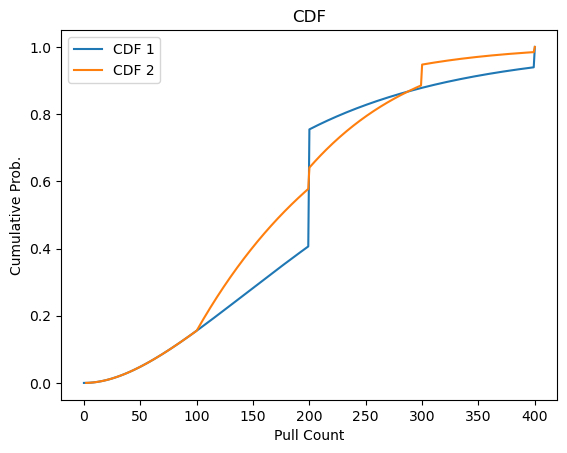

In [2]:
old_p_here = 1
new_p_here = 1
old_pmf = []
new_pmf = []
for n in range(1, 201):
    # update old prob.
    if n == 200:
        old_pmf.append(old_p_here)
    else:
        old_pmf.append(old_p_here * p)
        old_p_here *= pf
    # update new prob.
    if n == 100:
        new_pmf.append(new_p_here * 0.5)
        new_p_here *= 0.5
    elif n == 200:
        new_pmf.append(new_p_here)
    else:
        new_pmf.append(new_p_here * p)
        new_p_here *= pf

old_cdf = np.cumsum(old_pmf)
new_cdf = np.cumsum(new_pmf)

# old prob.
plan_sequence = [2]
n2, old_pmf2, old_cdf2, x_title = calc.calc_plan_sequence(batch_count, pulls_per_batch, cost_per_pull, single_pull_prob, plan_sequence, predict_cost_sequence, mode, total_cost)

# new prob.
new_pmf2 = np.convolve(new_pmf, new_pmf)
new_cdf2 = np.cumsum(new_pmf2)


plt.plot(n2, old_cdf2, label="CDF 1")
plt.plot(n2[2:], new_cdf2, label="CDF 2")
plt.title("CDF")
plt.xlabel("Pull Count")
plt.ylabel("Cumulative Prob.")
plt.legend()

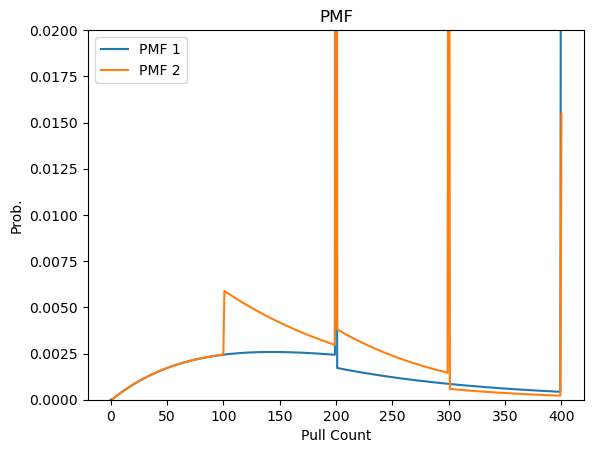

In [3]:
plt.plot(n2, old_pmf2, label="PMF 1")
plt.plot(n2[2:], new_pmf2, label="PMF 2")
plt.ylim(0, 0.02)
plt.title("PMF")
plt.xlabel("Pull Count")
plt.ylabel("Prob.")
plt.legend()

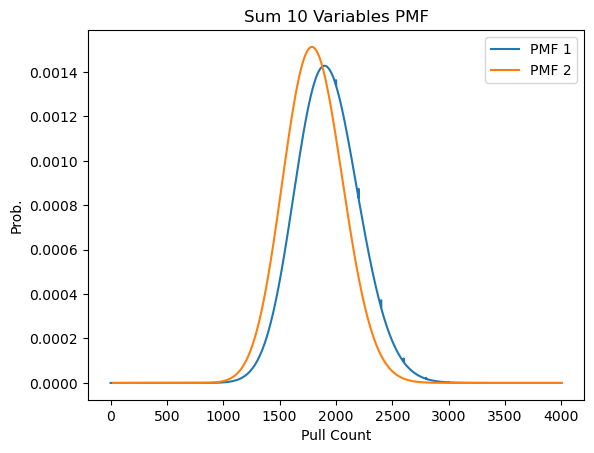

In [4]:
# old prob.
plan_sequence = [2] * 10
nx, old_pdfx, old_cdfx, x_title = calc.calc_plan_sequence(batch_count, pulls_per_batch, cost_per_pull, single_pull_prob, plan_sequence, predict_cost_sequence, mode, total_cost)

# new prob.
N = 20
new_pmfx = new_pmf
for _ in range(N-1):
    new_pmfx = np.convolve(new_pmfx, new_pmf)

plt.plot(nx, old_pdfx, label="PMF 1")
plt.plot(nx[N:], new_pmfx, label="PMF 2")
plt.title("Sum 10 Variables PMF")
plt.xlabel("Pull Count")
plt.ylabel("Prob.")
plt.legend()

### **Normal distribution !!!**